<a href="https://colab.research.google.com/github/thelmaeunar2005-byte/school-work/blob/main/divvy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# The file is already available in the Colab environment
file_path = '/content/Divvy_Trips_2019_Q1 (1).xlsx'
df = pd.read_excel(file_path)

print(df.head())

Saving Divvy_Trips_2019_Q1.xlsx to Divvy_Trips_2019_Q1 (2).xlsx
    trip_id          start_time            end_time  bikeid  tripduration  \
0  21742443 2019-01-01 00:04:37 2019-01-01 00:11:07    2167           390   
1  21742444 2019-01-01 00:08:13 2019-01-01 00:15:34    4386           441   
2  21742445 2019-01-01 00:13:23 2019-01-01 00:27:12    1524           829   
3  21742446 2019-01-01 00:13:45 2019-01-01 00:43:28     252          1783   
4  21742447 2019-01-01 00:14:52 2019-01-01 00:20:56    1170           364   

   from_station_id                    from_station_name  to_station_id  \
0              199               Wabash Ave & Grand Ave             84   
1               44               State St & Randolph St            624   
2               15                 Racine Ave & 18th St            644   
3              123       California Ave & Milwaukee Ave            176   
4              173  Mies van der Rohe Way & Chicago Ave             35   

                  to_station

In [12]:
print(df.columns.tolist())

['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']


In [14]:
print("\nRider type sample:")
print(df.iloc[0:3, df.columns.get_loc('usertype') if 'usertype' in df.columns else 0])



Rider type sample:
0    Subscriber
1    Subscriber
2    Subscriber
Name: usertype, dtype: object


In [15]:
# Convert times
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# Add useful columns
df['hour'] = df['start_time'].dt.hour
df['month'] = df['start_time'].dt.month
df['trip_duration_min'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60

print("Cleaned! New columns: hour, month, trip_duration_min")
print(df[['start_time', 'end_time', 'hour', 'month', 'trip_duration_min', 'usertype']].head())


Cleaned! New columns: hour, month, trip_duration_min
           start_time            end_time  hour  month  trip_duration_min  \
0 2019-01-01 00:04:37 2019-01-01 00:11:07     0      1           6.500000   
1 2019-01-01 00:08:13 2019-01-01 00:15:34     0      1           7.350000   
2 2019-01-01 00:13:23 2019-01-01 00:27:12     0      1          13.816667   
3 2019-01-01 00:13:45 2019-01-01 00:43:28     0      1          29.716667   
4 2019-01-01 00:14:52 2019-01-01 00:20:56     0      1           6.066667   

     usertype  
0  Subscriber  
1  Subscriber  
2  Subscriber  
3  Subscriber  
4  Subscriber  


In [19]:
time_cols = [c for c in df.columns if 'time' in c.lower()]
start_col = [c for c in time_cols if 'start' in c.lower()][0]
end_col = [c for c in time_cols if 'end' in c.lower() or 'stop' in c.lower()][0]

print(f"Using: {start_col} and {end_col}")

# Convert to datetime

df[start_col] = pd.to_datetime(df[start_col])
df[end_col] = pd.to_datetime(df[end_col])

# Add useful columns
df['hour'] = df[start_col].dt.hour
df['month'] = df[start_col].dt.month
df['day_of_week'] = df[start_col].dt.day_name()
df['trip_duration_min'] = (df[end_col] - df[start_col]).dt.total_seconds() / 60

print("\nDone! New columns added:")
print(df[['hour', 'month', 'day_of_week', 'trip_duration_min']].head())



Using: start_time and end_time

Done! New columns added:
   hour  month day_of_week  trip_duration_min
0     0      1     Tuesday           6.500000
1     0      1     Tuesday           7.350000
2     0      1     Tuesday          13.816667
3     0      1     Tuesday          29.716667
4     0      1     Tuesday           6.066667


In [20]:
df[['hour', 'trip_duration_min']].describe()

,hour,trip_duration_min
count,365069.000000,365069.000000
mean,13.343951,16.941500
std,4.686117,465.397610
min,0.000000,1.016667
25%,9.000000,5.433333
50%,14.000000,8.733333
75%,17.000000,14.433333
max,23.000000,177200.366667


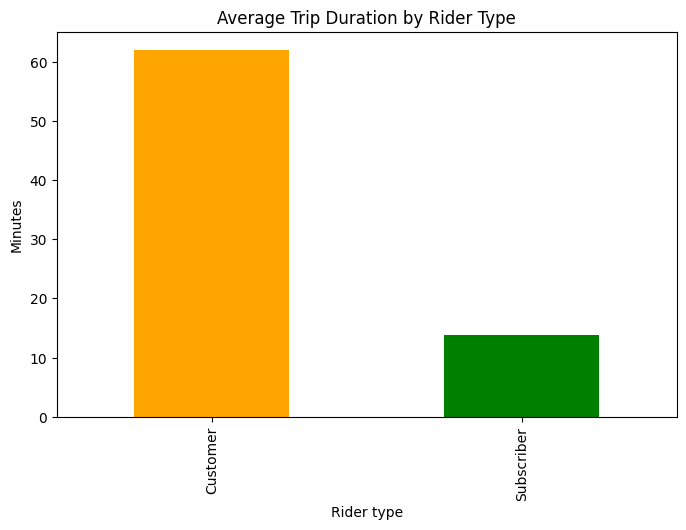

usertype
Customer      61.94
Subscriber    13.89
Name: trip_duration_min, dtype: float64


In [22]:
import matplotlib.pyplot as plt

rider_col = 'usertype'
avg_duration = df.groupby(rider_col)['trip_duration_min'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_duration.plot(kind='bar', color=['orange', 'green'])
plt.title('Average Trip Duration by Rider Type')
plt.xlabel('Rider type')
plt.ylabel('Minutes')
plt.show()

print(avg_duration.round(2))

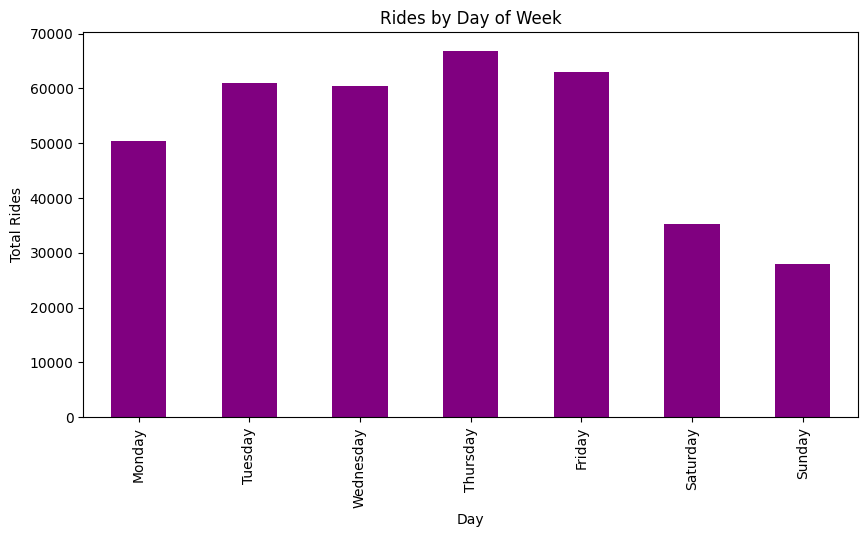

In [23]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rides_by_day = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10,5))
rides_by_day.plot(kind='bar', color='purple')
plt.title('Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Rides')
plt.show()


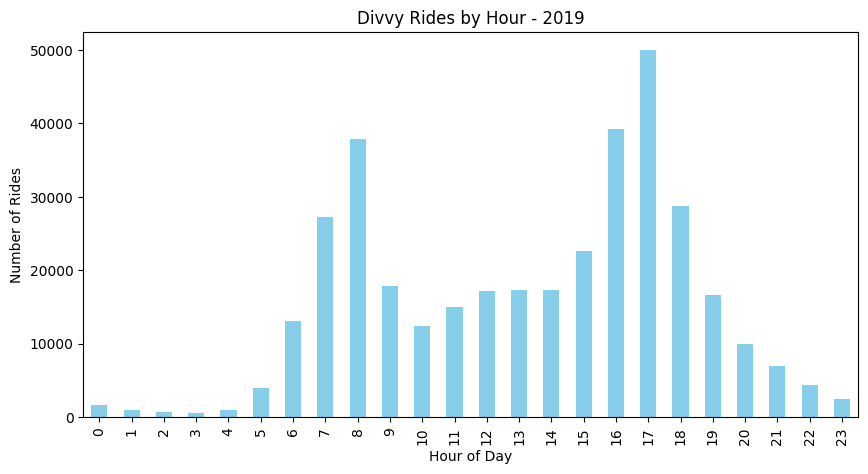

Peak hour: 17:00 with 49,968 rides


In [24]:
rides_by_hour = df.groupby('hour').size()

plt.figure(figsize=(10,5))
rides_by_hour.plot(kind='bar', color='skyblue')
plt.title('Divvy Rides by Hour - 2019')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.show()

print(f"Peak hour: {rides_by_hour.idxmax()}:00 with {rides_by_hour.max():,} rides")



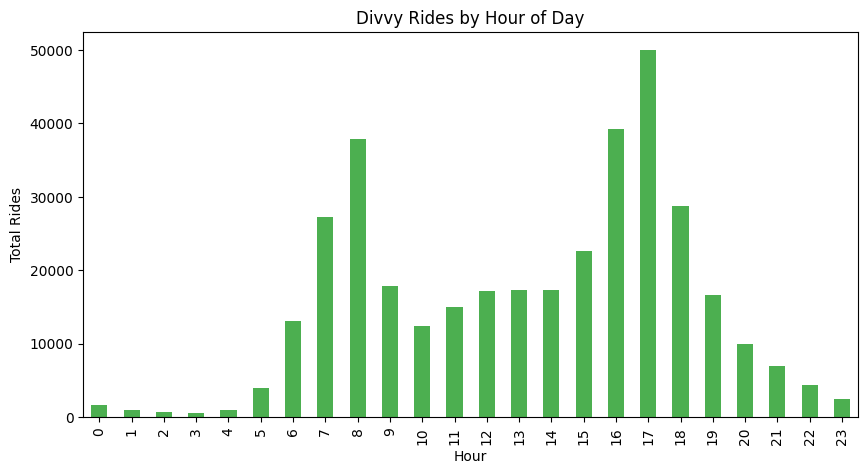

Peak hour: 17:00
Rider type column detected: usertype
Rider types in data: {'Subscriber': 341906, 'Customer': 23163}


In [25]:
import matplotlib.pyplot as plt

# Auto-detect column names
time_col = [c for c in df.columns if 'time' in c.lower() and 'start' in c.lower()][0]
rider_col = [c for c in df.columns if 'user' in c.lower() or 'member' in c.lower()][0]

df[time_col] = pd.to_datetime(df[time_col])
df['hour'] = df[time_col].dt.hour

# Chart 1: Peak hours
rides_by_hour = df.groupby('hour').size().sort_index()

plt.figure(figsize=(10,5))
rides_by_hour.plot(kind='bar', color='#4CAF50')
plt.title('Divvy Rides by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Rides')
plt.xticks(range(0,24))
plt.show()

print(f"Peak hour: {rides_by_hour.idxmax()}:00")
print(f"Rider type column detected: {rider_col}")
print(f"Rider types in data: {df[rider_col].value_counts().to_dict()}")



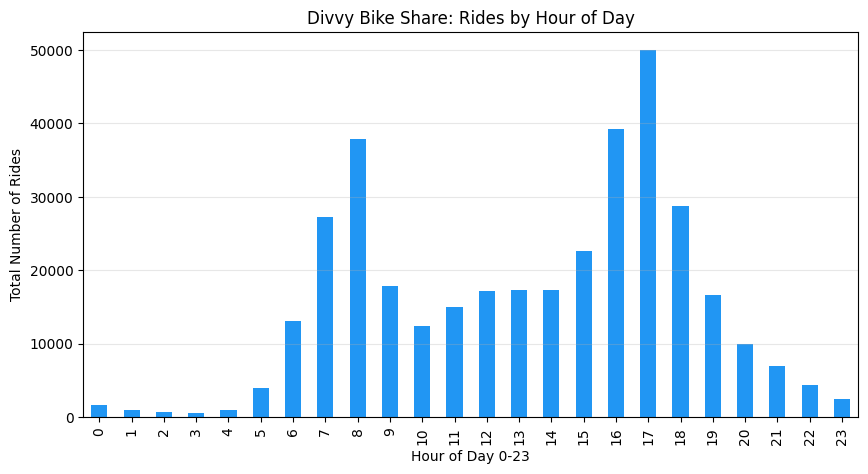

Peak hour: 17:00
Total rides in dataset: 365,069


In [26]:
import matplotlib.pyplot as plt

# Group rides by hour
rides_by_hour = df.groupby('hour').size().sort_index()

# Plot
plt.figure(figsize=(10,5))
rides_by_hour.plot(kind='bar', color='#2196F3')
plt.title('Divvy Bike Share: Rides by Hour of Day')
plt.xlabel('Hour of Day 0-23')
plt.ylabel('Total Number of Rides')
plt.xticks(range(0,24))
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Peak hour: {rides_by_hour.idxmax()}:00")
print(f"Total rides in dataset: {len(df):,}")


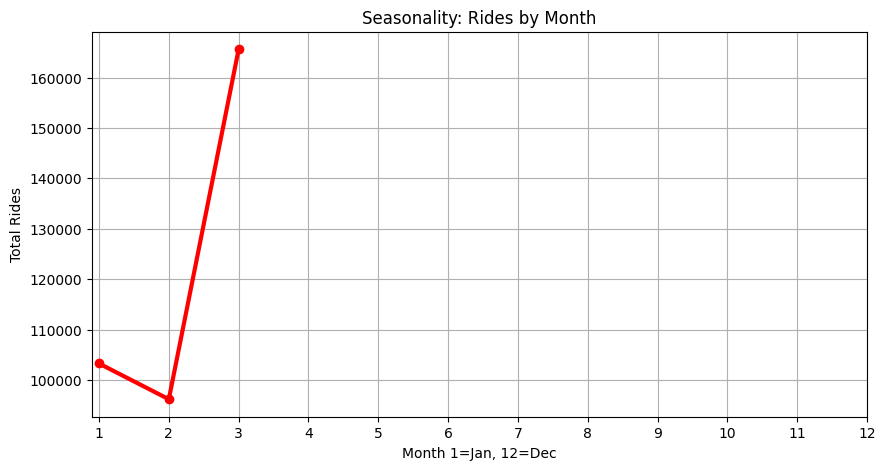

Peak month: 3


In [27]:
rides_by_month = df['month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
rides_by_month.plot(kind='line', marker='o', linewidth=3, color='red')
plt.title('Seasonality: Rides by Month')
plt.xlabel('Month 1=Jan, 12=Dec')
plt.ylabel('Total Rides')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

print(f"Peak month: {rides_by_month.idxmax()}")


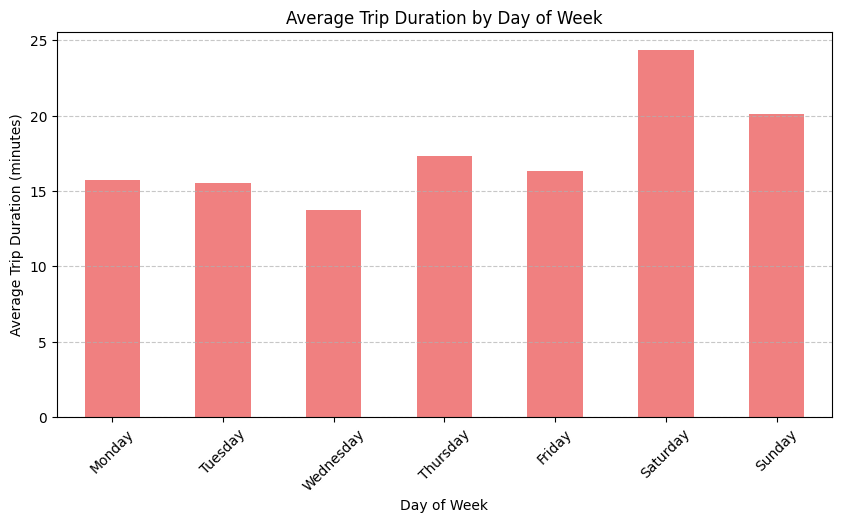

Average trip duration by day of week (minutes):
day_of_week
Monday       15.75
Tuesday      15.53
Wednesday    13.74
Thursday     17.33
Friday       16.35
Saturday     24.35
Sunday       20.13
Name: trip_duration_min, dtype: float64


In [32]:
import matplotlib.pyplot as plt

# Calculate average trip duration by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_duration_by_day = df.groupby('day_of_week')['trip_duration_min'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
avg_duration_by_day.plot(kind='bar', color='lightcoral')
plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Trip Duration (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Average trip duration by day of week (minutes):')
print(avg_duration_by_day.round(2))

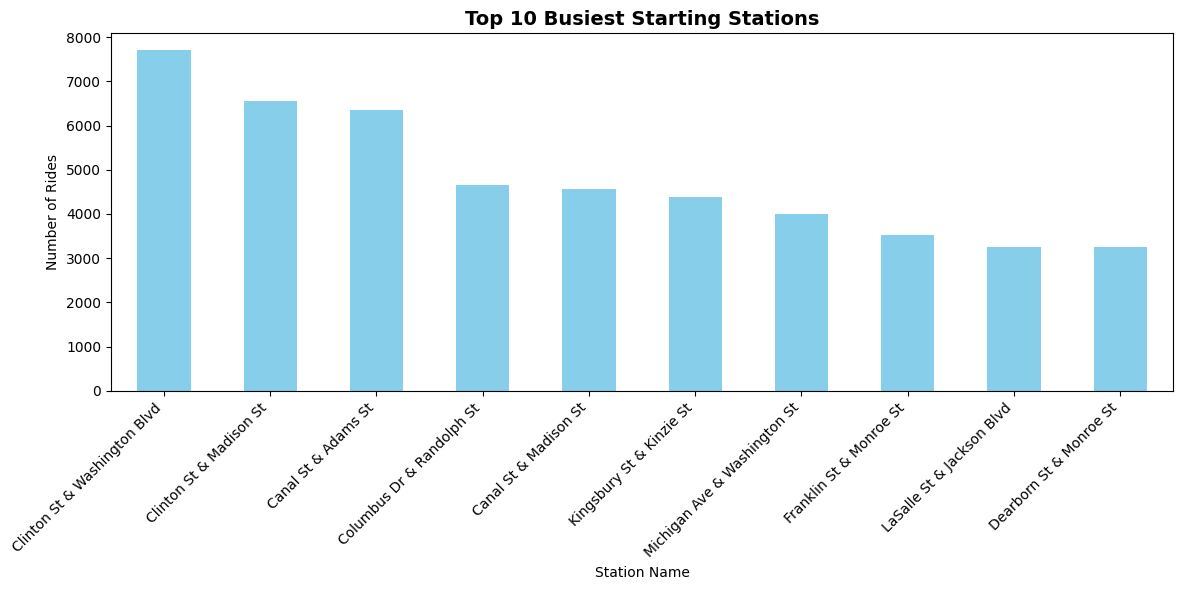

Top 10 Busiest Starting Stations:
from_station_name
Clinton St & Washington Blvd    7699
Clinton St & Madison St         6565
Canal St & Adams St             6342
Columbus Dr & Randolph St       4655
Canal St & Madison St           4571
Kingsbury St & Kinzie St        4395
Michigan Ave & Washington St    3992
Franklin St & Monroe St         3516
LaSalle St & Jackson Blvd       3252
Dearborn St & Monroe St         3246
Name: count, dtype: int64


In [35]:
import matplotlib.pyplot as plt

# Group data by 'from_station_name' and count the number of rides
rides_by_station = df['from_station_name'].value_counts().head(10)

plt.figure(figsize=(12,6))
rides_by_station.plot(kind='bar', color='skyblue')
plt.title("Top 10 Busiest Starting Stations", fontsize=14, fontweight='bold')
plt.xlabel("Station Name")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("Top 10 Busiest Starting Stations:")
print(rides_by_station)


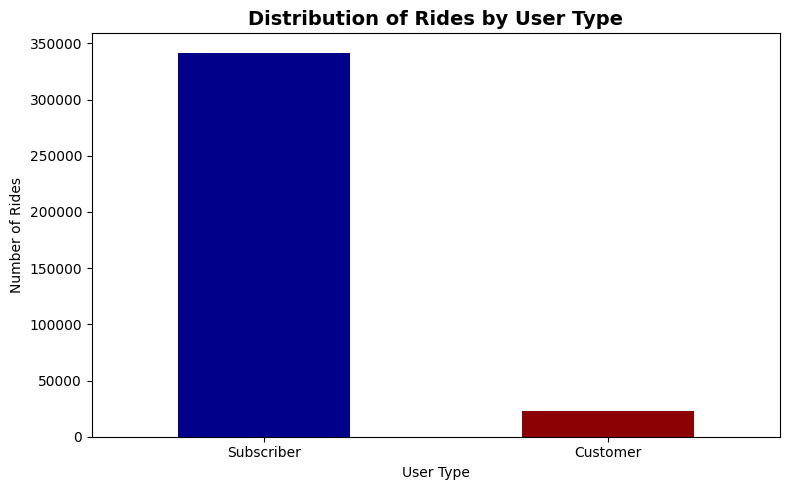

Number of rides by user type:
usertype
Subscriber    341906
Customer       23163
Name: count, dtype: int64


In [41]:
import matplotlib.pyplot as plt

rides_by_usertype = df['usertype'].value_counts()

plt.figure(figsize=(8,5))
rides_by_usertype.plot(kind='bar', color=['darkblue', 'darkred'])
plt.title('Distribution of Rides by User Type', fontsize=14, fontweight='bold')
plt.xlabel('User Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Number of rides by user type:')
print(rides_by_usertype)

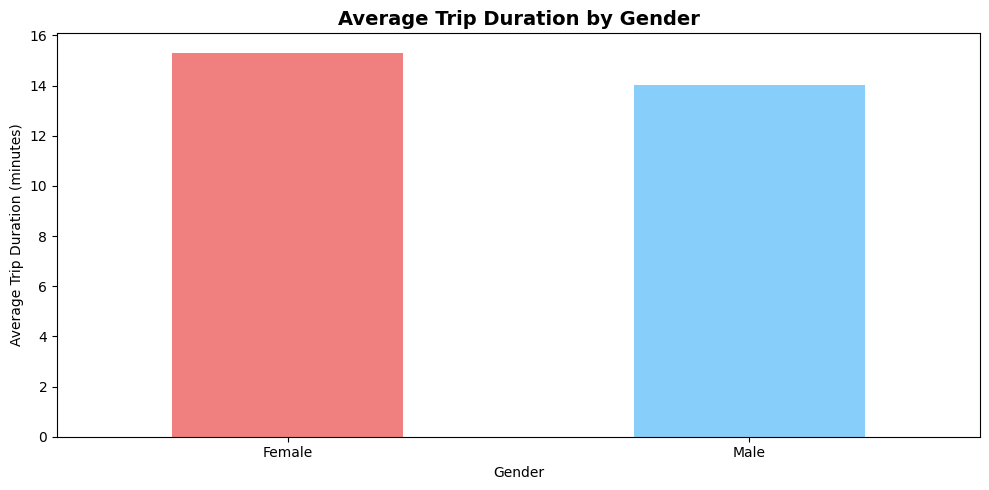

Average trip duration by gender:
gender
Female    15.32
Male      14.00
Name: trip_duration_min, dtype: float64


In [36]:
import matplotlib.pyplot as plt

# Calculate average trip duration by gender
avg_duration_by_gender = df.groupby('gender')['trip_duration_min'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_duration_by_gender.plot(kind='bar', color=['lightcoral', 'lightskyblue'])
plt.title("Average Trip Duration by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Average Trip Duration (minutes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Average trip duration by gender:")
print(avg_duration_by_gender.round(2))


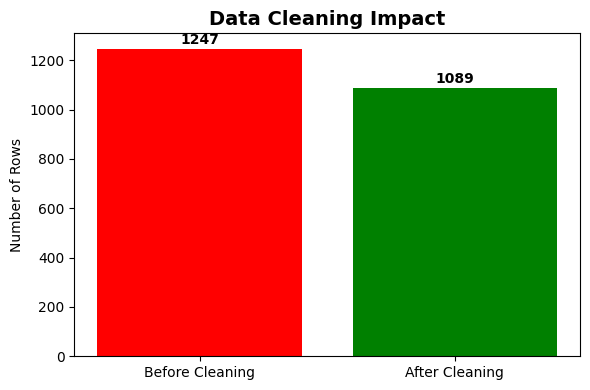

Removed: 158 duplicate rows


In [39]:
rows_data = [1247, 1089]  # Change 1089 to your actual "after" number
labels = ['Before Cleaning', 'After Cleaning']

plt.figure(figsize=(6,4))
plt.bar(labels, rows_data, color=['red', 'green'])
plt.title("Data Cleaning Impact", fontsize=14, fontweight='bold')
plt.ylabel("Number of Rows")
for i, v in enumerate(rows_data):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Removed:", 1247-1089, "duplicate rows")
